In [ ]:
# Inflation example

# restart the kernel to clear past work
# (can also do this manually from the Kernel options above)
from IPython.core.display import HTML
HTML("<script>Jupyter.notebook.kernel.restart()</script>")

In [1]:
# load the required python modules
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import time
import sys
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

# homemade source code from source folder
sys.path.append('../source')

from initialdata.inflationinitialconditions import *
from backgrounds.sphericalbackground import *
from bssn.constraintsdiagnostic import *
from bssn.ahfinder import *
from core.rhsevolution import *
from core.grid import Grid
from core.spacing import *
from core.display import *
from core.statevector import *
from matter.scalarmatter import *

In [2]:
# Set up the chosen matter class
scalar_mu = 1.0
my_matter = ScalarMatter(scalar_mu)
my_state_vector = StateVector(my_matter)

# Input parameters for grid and evolution here
r_max = 20.0 # outer edge of the grid (including ghosts)
min_dr = 1 / 100 #
max_dr = 1 / 20

# SinhSpacing
# params = SinhSpacing.get_parameters(r_max, min_dr, max_dr)
# spacing = SinhSpacing(**params)

# CubicSpacing
params = CubicSpacing.get_parameters(r_max, min_dr, max_dr)
spacing = CubicSpacing(**params)

grid = Grid(spacing, my_state_vector)
r = grid.r
num_points = r.size
background = FlatSphericalBackground(r)

# Check grid params
print(params)

{'r_max': 20.0, 'extent': <SpacingExtent.HALF: 0>, 'a': 4.2857142857142865, 'num_points': 861}


error is:  156.3619517722288  after iter:  200


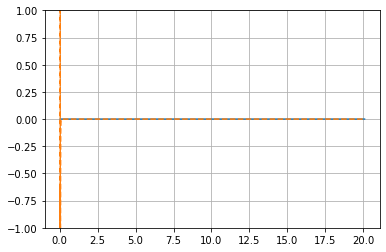

In [3]:
initial_state = get_initial_state(grid, background)

#unpackage the vector for readability
(initial_phi, initial_hrr, initial_htt, initial_hpp, 
 initial_K, initial_arr, initial_att, initial_app, 
 initial_lambdar, initial_shiftr, initial_br, initial_lapse, 
 initial_u, initial_v) = np.array_split(initial_state, grid.NUM_VARS)

(-10.5, 2.5)

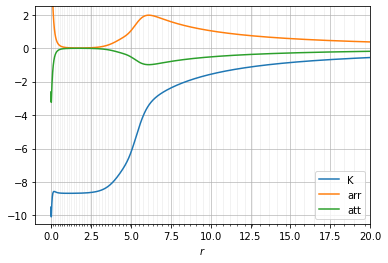

In [5]:
#plot initial conditions
plt.xlabel('r')
#plt.plot(r, initial_u, label='u')
#plt.plot(r, initial_v, label='v')
plt.plot(r, initial_K, label='K')
plt.plot(r, initial_arr, label='arr')
plt.plot(r, initial_att, label='att')
#plt.plot(r, initial_phi, label='phi')
#plt.plot(r, initial_hrr, '.', label='hrr') # zero, but plot as dots to see the grid
#plt.plot(r, initial_lapse, label='lapse')
#plt.plot(r, initial_lambdar, label='lambdar')
plt.legend(loc='best')
ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
plt.xlim(-1,20)
plt.ylim(-10.5,2.5)

(-0.002, 0.002)

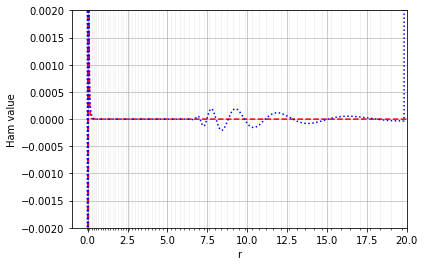

In [4]:
# check the Hamiltonian and momentum constraints are initially satisfied
Ham, Mom = get_constraints_diagnostic(initial_state, np.array([0]), grid, background, my_matter)

# plot the profile for Ham
ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
plt.plot(r, Ham[0], 'r--')
plt.plot(r, Mom[0,:,0], 'b:')

plt.xlabel('r')
plt.ylabel('Ham value')
plt.xlim(-1,20)
plt.ylim(-0.002,0.002)

horizon is at r = 0.0


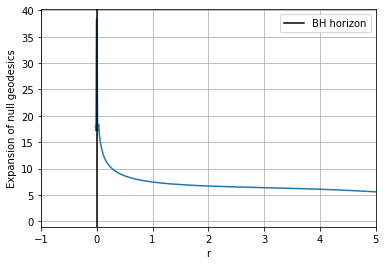

In [11]:
# find the apparent horizon for a given set of states
omega, ah_radius, bh_mass = get_horizon_diagnostics(initial_state, np.array([0]), grid, background, my_matter)

# plot the null expansion omega and its zero crossing
plt.plot(r, omega[0])
plt.axvline(x=ah_radius[0],c="k",label="BH horizon")
plt.xlabel('r')
plt.ylabel('Expansion of null geodesics')
plt.legend(loc="best")
#ax = plt.gcf().gca()
#set_grid_on_ax(ax, r)
plt.xlim(-1.0,5)
#plt.ylim(-5,5)
plt.grid()

print("horizon is at r =", round(ah_radius[0],1))

In [6]:
# for control of time integrator and spatial grid
T = 1 # Maximum evolution time
num_points_t = 256 # time resolution (only for outputs, not for integration, which is decided by python)

# Work out dt and time spacing of outputs
dt = T/num_points_t
t = np.linspace(0, T-dt, num_points_t)

# Solve for the solution using RK45 integration of the ODE
# to make like (older) python odeint method use method='LSODA' instead
# use tqdm package to track progress
with tqdm(total=1000, unit="‰") as progress_bar:
    dense_solution = solve_ivp(get_rhs, [0,T], initial_state, 
                               args=(grid, background, my_matter, progress_bar, [0, T/1000]),
                        #atol=1e-5, rtol=1e-5,
                        max_step = 0.4 * min_dr, #for stability and for KO coeff of 1
                        method='RK45', dense_output=True)

# Interpolate the solution at the time points requested
solution = dense_solution.sol(t).T

  0%|          | 0/1000 [00:00<?, ?‰/s]

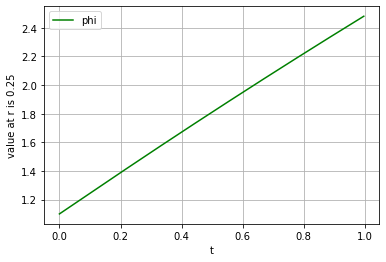

In [7]:
# Plot a single point versus time
var1 = my_matter.idx_u
var2 = idx_phi

idx = NUM_GHOSTS + 2 # Choose an inner point
r_i = np.round(r[idx],2)
var1_of_t = solution[:, var1 * num_points + idx]
#plt.plot(t, var1_of_t, 'b-', label=my_state_vector.VARIABLE_NAMES[var1])
var2_of_t = solution[:, var2 * num_points + idx]
plt.plot(t, var2_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var2])
plt.legend(loc='best')
plt.xlabel('t')
#plt.xlim(20,28)
plt.ylabel('value at r is '+str(r_i))
plt.legend(loc='best')
plt.grid()

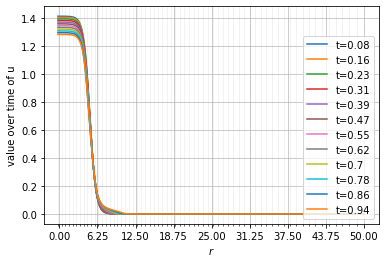

In [8]:
# plot the profile for some variable at a selection of times
var = my_matter.idx_u
#var = idx_K

for i, t_i in enumerate(t) :
    if (i < num_points_t) and (i % 20 == 0) and (t_i > 0.0) and (t_i < 100.0):
        labelt = "t="+str(round(t_i,2))
        f_t = solution[i, var * num_points: (var + 1) * num_points]
        plt.plot(r, f_t, label=labelt)

plt.legend(loc=4)
plt.xlabel('r')
plt.ylabel('value over time of ' + my_state_vector.VARIABLE_NAMES[var])
ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
#plt.xlim(-0.1,3.0)
#plt.ylim(0.999,1.001)

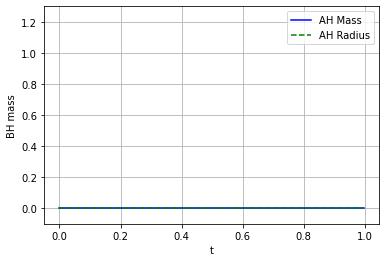

In [9]:
# Track the BH mass, show constant despite gauge evolution
omega, ah_radius, bh_mass = get_horizon_diagnostics(solution, t, grid, background, my_matter)

plt.plot(t, bh_mass, 'b-', label="AH Mass")
plt.plot(t, ah_radius, 'g--', label="AH Radius")
plt.legend(loc='best')
plt.xlabel('t')
plt.ylabel('BH mass')
plt.legend(loc='best')
plt.ylim(-0.1,1.3)
plt.grid()